# Experiment 5.1 — Boundary-free temporal decoder

Analysis-only notebook. Training and probes are produced by the Slurm workflow. Configuration selection uses validation balanced accuracy only; test balanced accuracy is reported only after selection.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
ART = ROOT / 'notebooks' / 'artifacts' / 'experiment_5_1_boundary_free_temporal_decoder' / 'frozen_local_leaky_interface_rsnn_v1'
runs = pd.read_csv(ART / 'runs.csv')
interface_probes = pd.read_csv(ART / 'interface_probes.csv')
histories = pd.read_csv(ART / 'histories.csv')
local_reference = pd.read_csv(ART / 'local_reference.csv')
manifest = json.loads((ART / 'manifest.json').read_text(encoding='utf-8'))
display(manifest)
display(runs.head())

{'aggregation_policy': 'finalizer concatenates only; notebook computes summaries, selection, paired effects, and plots',
 'aggregator_alpha': 0.9375,
 'aggregator_dc_mass_samples': 16.0,
 'aggregator_shift': 4,
 'aggregator_tau_ms_at_64hz': 242.10347130039656,
 'architectures': ['ff', 'rsnn'],
 'expected_decoder_runs': 48,
 'expected_interface_probe_runs': 6,
 'expected_local_cache_seeds': 3,
 'experiment_id': 'experiment_5_1_boundary_free_temporal_decoder',
 'files': {'histories': 'histories.csv',
  'interface_probes': 'interface_probes.csv',
  'local_reference': 'local_reference.csv',
  'runs': 'runs.csv'},
 'interfaces': ['raw_l2', 'leaky242'],
 'local_source_condition': 'exp3_exact_analog',
 'protocol_version': 'frozen_local_leaky_interface_rsnn_v1',
 'seeds': [11, 23, 101],
 'temporal_tau_mem_ms': [125.0, 250.0, 500.0, 1000.0]}

,interface,architecture,tau_mem_ms,seed,best_epoch,native_train_accuracy,native_train_balanced_accuracy,native_train_macro_f1,native_train_loss,native_train_hidden_events_per_neuron_second,...,hidden_whole_count_C,hidden_fixed250_ordered_val_ba,hidden_fixed250_ordered_test_ba,hidden_fixed250_ordered_C,hidden_relative10_ordered_val_ba,hidden_relative10_ordered_test_ba,hidden_relative10_ordered_C,hidden_uend_val_ba,hidden_uend_test_ba,hidden_uend_C
0,raw_l2,ff,125.0,11,94,0.927711,0.927284,0.927308,0.402147,23.466327,...,1.000,0.553096,0.568504,1.000,0.576972,0.616121,0.01,0.484235,0.524471,0.01
1,raw_l2,ff,125.0,23,65,0.895009,0.893018,0.894300,0.524432,23.578592,...,0.100,0.556884,0.607440,0.010,0.579413,0.620015,0.10,0.495256,0.469870,0.10
2,raw_l2,ff,125.0,101,71,0.900172,0.901116,0.900434,0.503117,24.372821,...,1.000,0.514923,0.552827,1.000,0.584981,0.557329,1.00,0.479383,0.454014,0.10
3,raw_l2,ff,250.0,11,29,0.839931,0.833132,0.834497,0.929285,21.332943,...,0.001,0.524411,0.568105,0.001,0.597054,0.554840,0.10,0.518236,0.522255,0.10
4,raw_l2,ff,250.0,23,35,0.839931,0.835604,0.834436,0.797300,22.485655,...,1.000,0.571278,0.555909,10.000,0.569529,0.657352,0.01,0.504942,0.492897,0.10


## 1. Aggregate native decoder performance

Mean ± SD is computed across the three frozen-local seeds.

In [2]:
native_summary = (
    runs.groupby(['interface', 'architecture', 'tau_mem_ms'])
    .agg(
        val_ba_mean=('native_val_balanced_accuracy', 'mean'),
        val_ba_sd=('native_val_balanced_accuracy', 'std'),
        test_ba_mean=('native_test_balanced_accuracy', 'mean'),
        test_ba_sd=('native_test_balanced_accuracy', 'std'),
        hidden_rate_mean=('native_test_hidden_events_per_neuron_second', 'mean'),
        hidden_tail_mean=('native_test_hidden_tail_event_fraction', 'mean'),
    )
    .reset_index()
)
display(native_summary.sort_values(['architecture', 'interface', 'tau_mem_ms']))

,interface,architecture,tau_mem_ms,val_ba_mean,val_ba_sd,test_ba_mean,test_ba_sd,hidden_rate_mean,hidden_tail_mean
0,leaky242,ff,125.0,0.439272,0.014302,0.444320,0.007886,24.999296,0.504956
1,leaky242,ff,250.0,0.420491,0.014447,0.403123,0.016729,24.973396,0.540493
2,leaky242,ff,500.0,0.390937,0.002619,0.371863,0.010081,24.892575,0.603731
3,leaky242,ff,1000.0,0.393426,0.011491,0.378464,0.025885,24.900969,0.672480
8,raw_l2,ff,125.0,0.521008,0.011039,0.529230,0.024610,24.244422,0.285107
9,raw_l2,ff,250.0,0.497872,0.019389,0.499959,0.036097,23.033452,0.287355
10,raw_l2,ff,500.0,0.498818,0.024186,0.519417,0.014867,23.335087,0.321335
11,raw_l2,ff,1000.0,0.491983,0.018697,0.503942,0.020236,23.182778,0.351939
4,leaky242,rsnn,125.0,0.440562,0.014051,0.448459,0.010485,25.616992,0.705582
5,leaky242,rsnn,250.0,0.418845,0.012801,0.414659,0.015283,24.834590,0.702717


## 2. Validation-only tau selection

For each interface × architecture, select tau only by mean validation native BA. Test metrics are joined only after the selection row is fixed.

In [3]:
selection = (
    native_summary.sort_values(['interface', 'architecture', 'val_ba_mean', 'tau_mem_ms'], ascending=[True, True, False, True])
    .groupby(['interface', 'architecture'], as_index=False)
    .first()
)
selection['test_ba_pct'] = 100 * selection['test_ba_mean']
display(selection[['interface', 'architecture', 'tau_mem_ms', 'val_ba_mean', 'test_ba_mean', 'test_ba_sd']])

,interface,architecture,tau_mem_ms,val_ba_mean,test_ba_mean,test_ba_sd
0,leaky242,ff,125.0,0.439272,0.444320,0.007886
1,leaky242,rsnn,125.0,0.440562,0.448459,0.010485
2,raw_l2,ff,125.0,0.521008,0.529230,0.024610
3,raw_l2,rsnn,125.0,0.487336,0.429132,0.001745


## 3. Native BA versus temporal memory

This plot answers whether leaky242 changes the temporal decoder ceiling and whether recurrence adds value beyond passive membrane state.

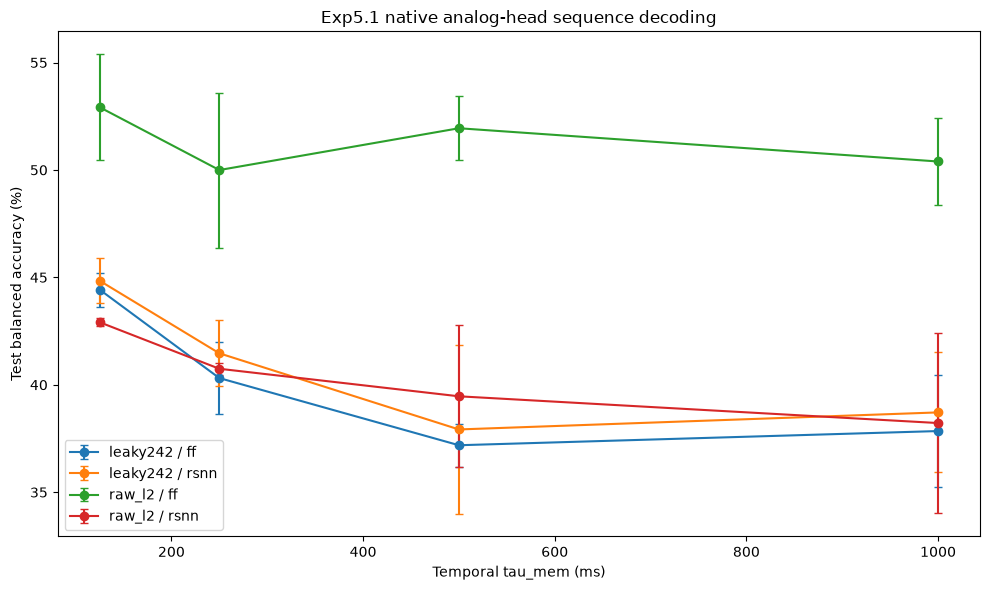

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
for (interface, architecture), group in native_summary.groupby(['interface', 'architecture']):
    group = group.sort_values('tau_mem_ms')
    ax.errorbar(group['tau_mem_ms'], 100 * group['test_ba_mean'], yerr=100 * group['test_ba_sd'], marker='o', capsize=3, label=f'{interface} / {architecture}')
ax.set_xlabel('Temporal tau_mem (ms)')
ax.set_ylabel('Test balanced accuracy (%)')
ax.set_title('Exp5.1 native analog-head sequence decoding')
ax.legend()
fig.tight_layout()
plt.show()

## 4. Paired effect of boundary-free pooling

Pair raw-L2 and leaky242 by seed within every architecture/tau. Positive values mean leaky242 improves native BA.

,architecture,tau_mem_ms,mean,std,count
0,ff,125.0,-0.084910,0.023052,3
1,ff,250.0,-0.096835,0.050848,3
2,ff,500.0,-0.147554,0.024293,3
3,ff,1000.0,-0.125478,0.037874,3
4,rsnn,125.0,0.019327,0.010606,3
5,rsnn,250.0,0.007200,0.013749,3
6,rsnn,500.0,-0.015432,0.006078,3
7,rsnn,1000.0,0.004954,0.028291,3


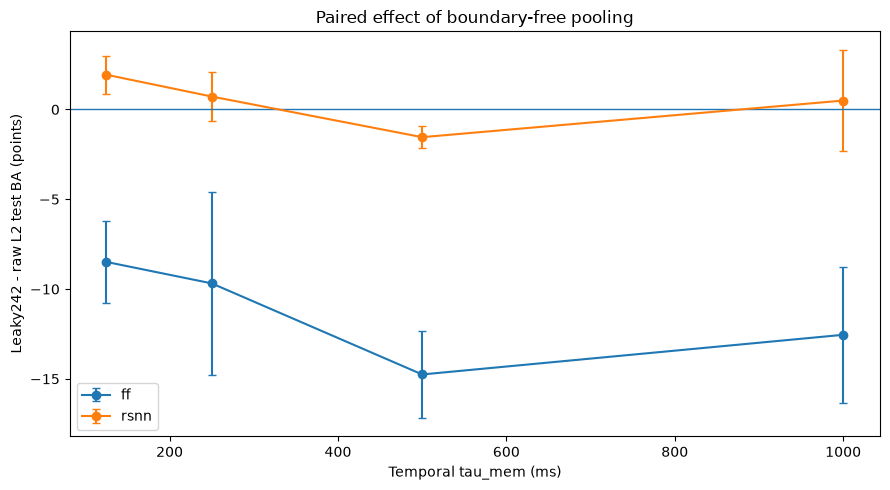

In [5]:
pivot = runs.pivot_table(index=['architecture', 'tau_mem_ms', 'seed'], columns='interface', values='native_test_balanced_accuracy').reset_index()
pivot['leaky_minus_raw'] = pivot['leaky242'] - pivot['raw_l2']
paired_pooling = (
    pivot.groupby(['architecture', 'tau_mem_ms'])['leaky_minus_raw']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
display(paired_pooling)
fig, ax = plt.subplots(figsize=(9, 5))
for architecture, group in paired_pooling.groupby('architecture'):
    group = group.sort_values('tau_mem_ms')
    ax.errorbar(group['tau_mem_ms'], 100 * group['mean'], yerr=100 * group['std'], marker='o', capsize=3, label=architecture)
ax.axhline(0, linewidth=1)
ax.set_xlabel('Temporal tau_mem (ms)')
ax.set_ylabel('Leaky242 - raw L2 test BA (points)')
ax.set_title('Paired effect of boundary-free pooling')
ax.legend()
fig.tight_layout()
plt.show()

## 5. Does leaky242 preserve phase-accessible information?

Interface probes are independent of FF/RSNN training. The key comparison is raw-L2 versus leaky242 for Fixed250/Relative10 accessibility and endpoint state.

,interface,probe_type,mean,std,count
0,leaky242,interface_endpoint,0.564134,0.007266,3
1,leaky242,interface_fixed250_ordered,0.562818,0.002911,3
2,leaky242,interface_relative10_ordered,0.629859,0.040151,3
3,leaky242,interface_valid_sum,0.539130,0.019155,3
4,raw_l2,interface_endpoint,0.391296,0.054518,3
5,raw_l2,interface_fixed250_ordered,0.625945,0.023422,3
6,raw_l2,interface_relative10_ordered,0.682000,0.035447,3
7,raw_l2,interface_valid_sum,0.557253,0.061306,3


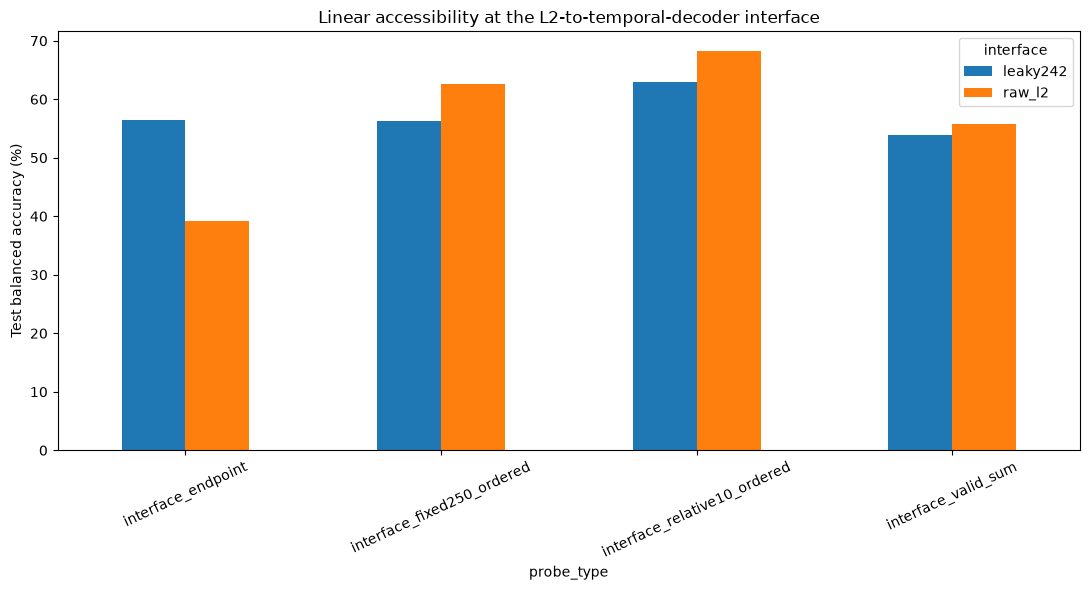

In [6]:
interface_summary = (
    interface_probes.groupby(['interface', 'probe_type'])['test_ba']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
display(interface_summary)
plot = interface_summary.pivot(index='probe_type', columns='interface', values='mean')
ax = (100 * plot).plot(kind='bar', figsize=(11, 6), rot=25)
ax.set_ylabel('Test balanced accuracy (%)')
ax.set_title('Linear accessibility at the L2-to-temporal-decoder interface')
fig = ax.get_figure()
fig.tight_layout()
plt.show()

## 6. Representation flow at validation-selected configurations

Compare the historical frozen L2 reference with interface and temporal-hidden probes. This is the main information-flow diagnostic.

In [7]:
local_metrics = pd.DataFrame({
    'stage': ['L2 FullCount', 'L2 Fixed250', 'L2 Relative10'],
    'test_ba': [
        local_reference['full_count_test_ba'].mean(),
        local_reference['fixed250_ordered_test_ba'].mean(),
        local_reference['relative10_ordered_test_ba'].mean(),
    ],
})
selected_rows = []
for _, selected in selection.iterrows():
    subset = runs[(runs.interface == selected.interface) & (runs.architecture == selected.architecture) & (runs.tau_mem_ms == selected.tau_mem_ms)]
    for metric, label in [
        ('hidden_whole_count_test_ba', 'Hidden WholeCount'),
        ('hidden_fixed250_ordered_test_ba', 'Hidden Fixed250'),
        ('hidden_relative10_ordered_test_ba', 'Hidden Relative10'),
        ('hidden_uend_test_ba', 'Hidden Uend'),
    ]:
        selected_rows.append({'interface': selected.interface, 'architecture': selected.architecture, 'tau_mem_ms': selected.tau_mem_ms, 'stage': label, 'test_ba': subset[metric].mean()})
selected_probe_table = pd.DataFrame(selected_rows)
display(local_metrics)
display(selected_probe_table)

,stage,test_ba
0,L2 FullCount,0.559237
1,L2 Fixed250,0.625945
2,L2 Relative10,0.682000


,interface,architecture,tau_mem_ms,stage,test_ba
0,leaky242,ff,125.0,Hidden WholeCount,0.449771
1,leaky242,ff,125.0,Hidden Fixed250,0.515355
2,leaky242,ff,125.0,Hidden Relative10,0.532473
3,leaky242,ff,125.0,Hidden Uend,0.571619
4,leaky242,rsnn,125.0,Hidden WholeCount,0.472369
5,leaky242,rsnn,125.0,Hidden Fixed250,0.518571
6,leaky242,rsnn,125.0,Hidden Relative10,0.525728
7,leaky242,rsnn,125.0,Hidden Uend,0.575988
8,raw_l2,ff,125.0,Hidden WholeCount,0.549975
9,raw_l2,ff,125.0,Hidden Fixed250,0.576257


## 7. State consolidation diagnostic

For RSNN, compare hidden Uend with hidden WholeCount and Relative10 across tau. If Uend approaches Relative10, recurrent state has consolidated temporal information that otherwise requires trajectory access.

,interface,tau_mem_ms,hidden_whole_count_test_ba,hidden_relative10_ordered_test_ba,hidden_uend_test_ba
0,leaky242,125.0,0.472369,0.525728,0.575988
1,leaky242,250.0,0.408981,0.512297,0.567162
2,leaky242,500.0,0.378039,0.445547,0.574478
3,leaky242,1000.0,0.371603,0.432735,0.570248
4,raw_l2,125.0,0.462844,0.551200,0.555080
5,raw_l2,250.0,0.455098,0.493135,0.568167
6,raw_l2,500.0,0.443585,0.523508,0.545905
7,raw_l2,1000.0,0.444936,0.505654,0.510553


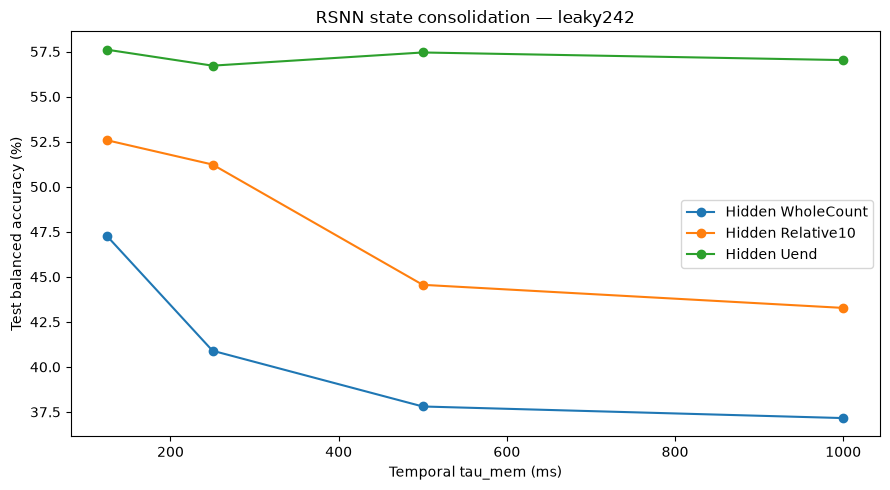

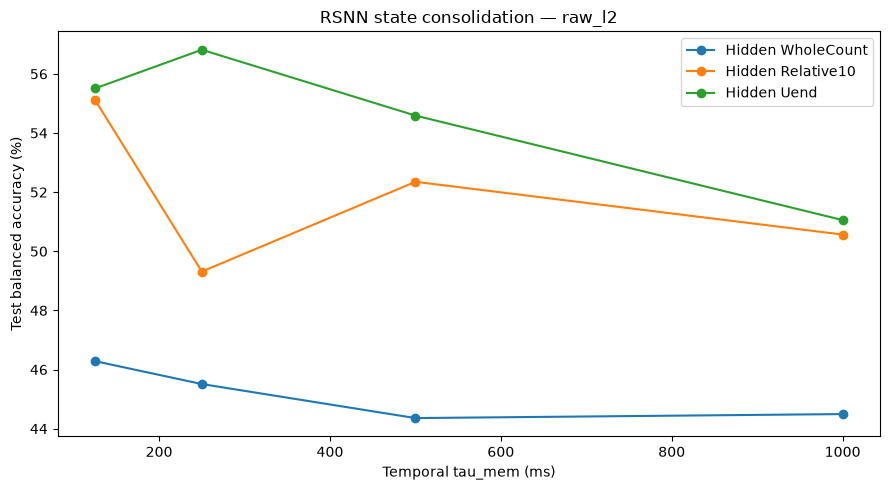

In [8]:
rsnn = runs[runs.architecture == 'rsnn']
probe_summary = (
    rsnn.groupby(['interface', 'tau_mem_ms'])[[
        'hidden_whole_count_test_ba',
        'hidden_relative10_ordered_test_ba',
        'hidden_uend_test_ba',
    ]]
    .mean()
    .reset_index()
)
display(probe_summary)
for interface, group in probe_summary.groupby('interface'):
    fig, ax = plt.subplots(figsize=(9, 5))
    group = group.sort_values('tau_mem_ms')
    ax.plot(group['tau_mem_ms'], 100 * group['hidden_whole_count_test_ba'], marker='o', label='Hidden WholeCount')
    ax.plot(group['tau_mem_ms'], 100 * group['hidden_relative10_ordered_test_ba'], marker='o', label='Hidden Relative10')
    ax.plot(group['tau_mem_ms'], 100 * group['hidden_uend_test_ba'], marker='o', label='Hidden Uend')
    ax.set_xlabel('Temporal tau_mem (ms)')
    ax.set_ylabel('Test balanced accuracy (%)')
    ax.set_title(f'RSNN state consolidation — {interface}')
    ax.legend()
    fig.tight_layout()
    plt.show()

## 8. Validation learning curves for the globally selected configuration

Global selection is based only on mean validation native BA. Curves show mean ± SD over seeds.

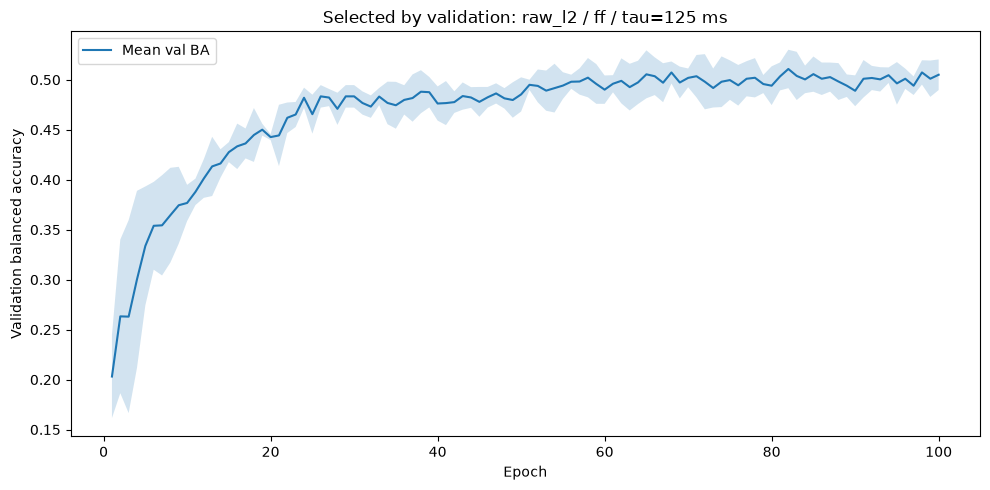

In [9]:
global_selected = native_summary.sort_values(['val_ba_mean', 'tau_mem_ms'], ascending=[False, True]).iloc[0]
curve = histories[(histories.interface == global_selected.interface) & (histories.architecture == global_selected.architecture) & (histories.tau_mem_ms == global_selected.tau_mem_ms)]
curve_summary = curve.groupby('epoch')['val_balanced_accuracy'].agg(['mean', 'std']).reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(curve_summary['epoch'], curve_summary['mean'], label='Mean val BA')
ax.fill_between(curve_summary['epoch'], curve_summary['mean'] - curve_summary['std'], curve_summary['mean'] + curve_summary['std'], alpha=0.2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation balanced accuracy')
ax.set_title(f"Selected by validation: {global_selected.interface} / {global_selected.architecture} / tau={global_selected.tau_mem_ms:.0f} ms")
ax.legend()
fig.tight_layout()
plt.show()

## Interpretation gates

1. `leaky242 > raw_l2` in paired native BA: boundary-free aggregation reduces temporal-decoder burden.
2. Leaky242 interface Fixed250/Relative10 probe near raw-L2: smoothing preserves the useful local/phase representation.
3. `RSNN > FF`: learned recurrence adds value beyond passive membrane memory.
4. Hidden Uend approaching hidden Relative10: recurrent state consolidates phase/history into the current state.
5. Strong hidden probes but weak native analog head: decoder representation is good but class-evidence readout remains limiting.